## Dataset

1. We use the Bank Marketing Dataset from the UCI Machine Learning Repository.
Source: https://archive.ics.uci.edu/ml/datasets/bank+marketing

2. The data is related with direct marketing campaigns (phone calls) of a Portuguese banking institution. Originally designed for supervised learning, but we will ignore the label initially

Important Decision:

Even though the dataset contains subscribed (whether the client subscribed to a term deposit), we do not use it to train the clustering model.
We may, however, use it later for interpretation only.

    # bank client data:
    1 - age (numeric)
    2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
    3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
    4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
    5 - default: has credit in default? (categorical: 'no','yes','unknown')
    6 - housing: has housing loan? (categorical: 'no','yes','unknown')
    7 - loan: has personal loan? (categorical: 'no','yes','unknown')
    # related with the last contact of the current campaign:
    8 - contact: contact communication type (categorical: 'cellular','telephone')
    9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
    10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
    11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
    # other attributes:
    12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
    13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
    14 - previous: number of contacts performed before this campaign and for this client (numeric)
    15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
    # social and economic context attributes
    16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
    17 - cons.price.idx: consumer price index - monthly indicator (numeric)
    18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
    19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
    20 - nr.employed: number of employees - quarterly indicator (numeric)
    21 - y - has the client subscribed a term deposit? (binary: 'yes','no')

## task 1

### Requirements

The goal of this lab is to **explore the bank dataset, prepare it for clustering, and apply K-Means**.  
Follow these steps carefully and write down your observations.  

### **Exploratory Data Analysis (EDA)** (understanding the dataset and its characteristics)

For each feature, you should:

- Identify **numeric vs categorical features**  
- Check **distributions** of numeric features (min, max, mean, std, skewness)  
- Check **counts of categories** for categorical features  
- Identify **missing or unknown values** and decide how to handle them  
- Look for **correlations** between numeric features  
- Identify **outliers** that may affect clustering  

In [3]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
bank_marketing = fetch_ucirepo(id=222) 
  
# data (as pandas dataframes) 
X = bank_marketing.data.features 
y = bank_marketing.data.targets 
  
# metadata 
# print(bank_marketing.metadata) 
  
# variable information 
print(bank_marketing.variables) 


           name     role         type      demographic  \
0           age  Feature      Integer              Age   
1           job  Feature  Categorical       Occupation   
2       marital  Feature  Categorical   Marital Status   
3     education  Feature  Categorical  Education Level   
4       default  Feature       Binary             None   
5       balance  Feature      Integer             None   
6       housing  Feature       Binary             None   
7          loan  Feature       Binary             None   
8       contact  Feature  Categorical             None   
9   day_of_week  Feature         Date             None   
10        month  Feature         Date             None   
11     duration  Feature      Integer             None   
12     campaign  Feature      Integer             None   
13        pdays  Feature      Integer             None   
14     previous  Feature      Integer             None   
15     poutcome  Feature  Categorical             None   
16            

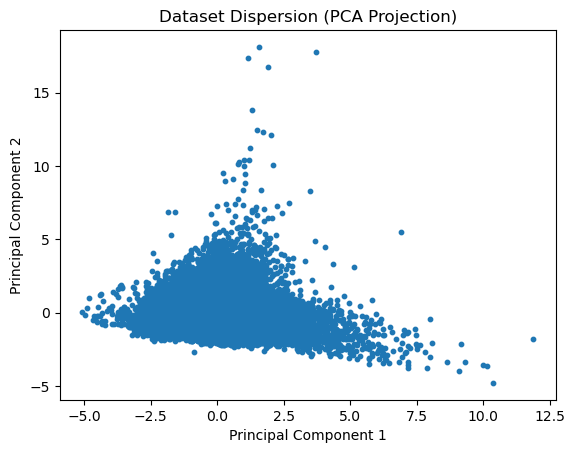

In [80]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce to 2 dimensions
pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X)

# Plot
plt.figure()
plt.scatter(X_pca2[:, 0], X_pca2[:, 1], s=10)
plt.title("Dataset Dispersion (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

In [4]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
print("Numeric features:")
print(numeric_features)

Numeric features:
Index(['age', 'balance', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous'],
      dtype='object')


In [5]:
categorical_features = X.select_dtypes(include=['object']).columns
print("Categorical features:")
print(categorical_features)

Categorical features:
Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='object')


In [6]:
X[numeric_features].describe().T

,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.936210,10.618762,18.0,33.0,39.0,48.0,95.0
balance,45211.0,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
day_of_week,45211.0,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0
duration,45211.0,258.163080,257.527812,0.0,103.0,180.0,319.0,4918.0
campaign,45211.0,2.763841,3.098021,1.0,1.0,2.0,3.0,63.0
pdays,45211.0,40.197828,100.128746,-1.0,-1.0,-1.0,-1.0,871.0
previous,45211.0,0.580323,2.303441,0.0,0.0,0.0,0.0,275.0


In [7]:
for col in categorical_features:
    print(f"\nColumn: {col}")
    print(X[col].value_counts())


Column: job
job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
Name: count, dtype: int64

Column: marital
marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64

Column: education
education
secondary    23202
tertiary     13301
primary       6851
Name: count, dtype: int64

Column: default
default
no     44396
yes      815
Name: count, dtype: int64

Column: housing
housing
yes    25130
no     20081
Name: count, dtype: int64

Column: loan
loan
no     37967
yes     7244
Name: count, dtype: int64

Column: contact
contact
cellular     29285
telephone     2906
Name: count, dtype: int64

Column: month
month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
apr     2932
feb     2649
jan     1403
oct      738
sep      579
mar      477
dec      214
Name: c

In [10]:
X.isnull().sum()

age                0
job              288
marital            0
education       1857
default            0
balance            0
housing            0
loan               0
contact        13020
day_of_week        0
month              0
duration           0
campaign           0
pdays              0
previous           0
poutcome       36959
dtype: int64

In [68]:
from sklearn.impute import SimpleImputer
#replaces the NaN with the most frequent values



#this may be something you would like to change
imputer = SimpleImputer(strategy="most_frequent")

In [69]:
correlation_matrix = X[numeric_features].corr()
print(correlation_matrix)

                  age   balance  day_of_week  campaign     pdays
age          1.000000  0.097783    -0.009120  0.004760 -0.023758
balance      0.097783  1.000000     0.004503 -0.014578  0.003435
day_of_week -0.009120  0.004503     1.000000  0.162490 -0.093044
campaign     0.004760 -0.014578     0.162490  1.000000 -0.088628
pdays       -0.023758  0.003435    -0.093044 -0.088628  1.000000


In [70]:
Q1 = X[numeric_features].quantile(0.25)
Q3 = X[numeric_features].quantile(0.75)
IQR = Q3 - Q1
outliers = ((X[numeric_features] < (Q1 - 1.5 * IQR)) |
            (X[numeric_features] > (Q3 + 1.5 * IQR)))
outliers.sum()
outlier_rows = X[outliers.any(axis=1)]
outlier_rows
# this computes the outliers. Here you can find the listed outliers

,age,balance,day_of_week,campaign,pdays,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,...,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success
34,0.947747,3.045499,-1.298476,-0.569351,-0.411453,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
65,0.947747,1.697268,-1.298476,-0.569351,-0.411453,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
69,-0.559037,3.567055,-1.298476,-0.569351,-0.411453,True,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
70,1.512791,1.501849,-1.298476,-0.569351,-0.411453,True,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
186,-0.088167,0.992445,-1.298476,-0.569351,-0.411453,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45201,1.136095,-0.255941,0.143418,-0.569351,1.436189,False,False,False,True,False,...,False,False,False,False,False,True,False,False,False,True
45204,3.019575,0.488624,0.143418,-0.569351,-0.001976,False,False,False,False,True,...,False,False,False,False,False,True,False,False,False,False
45207,2.831227,0.120447,0.143418,-0.246560,-0.411453,False,False,False,False,True,...,False,False,False,False,False,True,False,False,False,False
45208,2.925401,1.429593,0.143418,0.721811,1.436189,False,False,False,False,True,...,False,False,False,False,False,True,False,False,False,True


### **Data Preparation**

Before applying K-Means:

- Drop irrelevant or target columns
- Encode categorical features into numeric format
- Scale numeric features so all are comparable for distance calculations  
- Check that the final dataset has **no missing values** and **all features are numeric**  

In [72]:
print(X.columns)

Index(['age', 'balance', 'day_of_week', 'campaign', 'pdays', 'job_blue-collar',
       'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired',
       'job_self-employed', 'job_services', 'job_student', 'job_technician',
       'job_unemployed', 'marital_married', 'marital_single',
       'education_secondary', 'education_tertiary', 'default_yes',
       'housing_yes', 'loan_yes', 'contact_telephone', 'month_aug',
       'month_dec', 'month_feb', 'month_jan', 'month_jul', 'month_jun',
       'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep',
       'poutcome_other', 'poutcome_success'],
      dtype='object')


In [73]:
X_encoded = pd.get_dummies(X, drop_first=True)

In [74]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="most_frequent")
X_imputed = pd.DataFrame(imputer.fit_transform(X_encoded),
                         columns=X_encoded.columns)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_imputed),
                        columns=X_imputed.columns)
print(X_scaled.isnull().sum().sum())
X_final = X_scaled
print(X_final.select_dtypes(include=["number"]).shape[1] == X_final.shape[1])

0
True


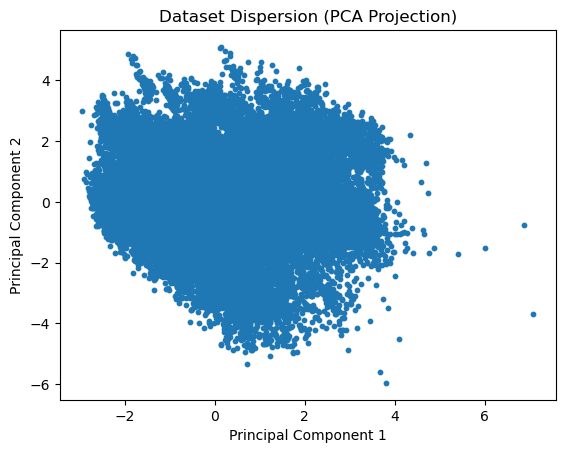

In [79]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce to 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_final)

# Plot
plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=10)
plt.title("Dataset Dispersion (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

### **Choosing the Convenient K**

- Use **Elbow Method**: plot Sum of Squared Distances (SSD) vs K  
- Identify the **elbow point** where SSD reduction slows  
- Calculate **Silhouette scores** to validate K  

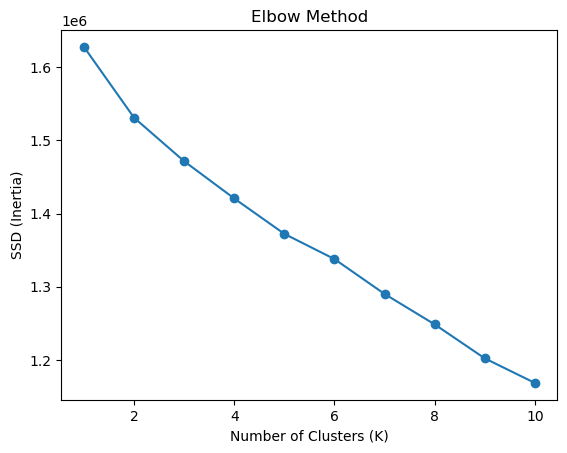

In [78]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

ssd = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    ssd.append(kmeans.inertia_)  # Sum of Squared Distances
plt.figure()
plt.plot(k_range, ssd, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("SSD (Inertia)")
plt.show()

#according to the graph below, we can see that there is no clear elbow shape, but maybe it will be on an extended range

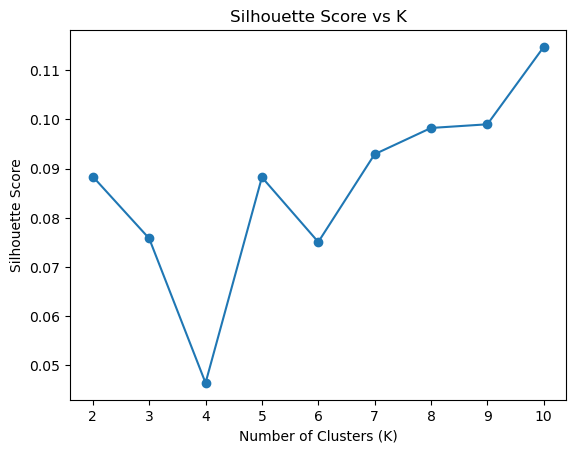

In [76]:
from sklearn.metrics import silhouette_score

sil_scores = []
k_range_sil = range(2, 11)

for k in k_range_sil:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_final)
    score = silhouette_score(X_final, labels)
    sil_scores.append(score)
plt.figure()
plt.plot(k_range_sil, sil_scores, marker='o')
plt.title("Silhouette Score vs K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.show()
# according to the graph, we can see that the best silhouette score is at a cluster =10, and maybe we can find a better on  an extended range.